# DeepFashion In-shop EDA

This notebook explores the dataset structure, annotations, and key statistics before training.

Run the cells top to bottom after the dataset is placed under data/.

In [55]:
from pathlib import Path
import json
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw
from IPython.display import display

sns.set_theme(style="whitegrid")
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)


def find_repo_root(start: Path) -> Path:
    for base in [start, *start.parents]:
        data_dir = base / "data"
        if not data_dir.is_dir():
            continue
        if (data_dir / "Anno").is_dir() and (data_dir / "Eval").is_dir() and (data_dir / "Img").is_dir():
            return base
    return None


CWD = Path.cwd()
PROJECT_ROOT = find_repo_root(CWD)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find data/Anno, data/Eval, and data/Img above {CWD}. Run this notebook from the repo root or the notebooks/ folder."
    )

DATA_ROOT = PROJECT_ROOT / "data"
ANNO_DIR = DATA_ROOT / "Anno"
EVAL_DIR = DATA_ROOT / "Eval"
IMG_DIR = DATA_ROOT / "Img" / "img"
IMG_ZIP = DATA_ROOT / "Img" / "img.zip"

if not IMG_DIR.exists() and IMG_ZIP.exists():
    print(f"Warning: {IMG_DIR} not found. Found {IMG_ZIP}. Unzip it to Img/img.")

PROJECT_ROOT, DATA_ROOT, ANNO_DIR, EVAL_DIR, IMG_DIR

(PosixPath('/home/saheem/Desktop/iiitb/imt2023_sem6/VR/project2/github_repo/DeepFashion-In-shop-Clothes-Retrieval_'),
 PosixPath('/home/saheem/Desktop/iiitb/imt2023_sem6/VR/project2/github_repo/DeepFashion-In-shop-Clothes-Retrieval_/data'),
 PosixPath('/home/saheem/Desktop/iiitb/imt2023_sem6/VR/project2/github_repo/DeepFashion-In-shop-Clothes-Retrieval_/data/Anno'),
 PosixPath('/home/saheem/Desktop/iiitb/imt2023_sem6/VR/project2/github_repo/DeepFashion-In-shop-Clothes-Retrieval_/data/Eval'),
 PosixPath('/home/saheem/Desktop/iiitb/imt2023_sem6/VR/project2/github_repo/DeepFashion-In-shop-Clothes-Retrieval_/data/Img/img'))

## Load and Parse Metadata Files

This section reads the core annotation files into pandas DataFrames.

In [56]:
def read_table_with_header(path):
    path = Path(path)
    if not path.exists():
        print(f"Missing: {path}")
        return None, None, None
    with path.open() as f:
        first = f.readline().strip()
        header = f.readline().strip().split()
    try:
        n_expected = int(first)
    except ValueError:
        n_expected = None
    df = pd.read_csv(path, sep=r"\s+", skiprows=2, header=None, names=header, engine="python")
    return df, n_expected, header


def read_id_list(path):
    path = Path(path)
    if not path.exists():
        print(f"Missing: {path}")
        return None, None
    lines = path.read_text().splitlines()
    try:
        n_expected = int(lines[0])
    except (ValueError, IndexError):
        n_expected = None
    values = [line.strip() for line in lines[1:] if line.strip()]
    df = pd.DataFrame({"item_id": values})
    return df, n_expected


def read_attr_list(path):
    path = Path(path)
    if not path.exists():
        print(f"Missing: {path}")
        return None, None
    lines = path.read_text().splitlines()
    try:
        n_expected = int(lines[0])
    except (ValueError, IndexError):
        n_expected = None
    values = [line.strip() for line in lines[2:] if line.strip()]
    df = pd.DataFrame({"attribute": values})
    return df, n_expected


def read_descriptions(path):
    path = Path(path)
    if not path.exists():
        print(f"Missing: {path}")
        return None
    with path.open() as f:
        data = json.load(f)

    if isinstance(data, list):
        df = pd.DataFrame(data)
        if df.shape[1] >= 3:
            df = df.rename(columns={df.columns[0]: "item_id", df.columns[1]: "color", df.columns[2]: "description"})
        return df

    if isinstance(data, dict):
        if all(isinstance(v, dict) for v in data.values()):
            df = pd.DataFrame.from_dict(data, orient="index").reset_index().rename(columns={"index": "item_id"})
        else:
            df = pd.DataFrame({"item_id": list(data.keys()), "description": list(data.values())})
        return df

    return None


def pick_col(df, candidates, default_idx=0):
    if df is None:
        return None
    for name in candidates:
        if name in df.columns:
            return name
    return df.columns[default_idx]


eval_df, eval_expected, _ = read_table_with_header(EVAL_DIR / "list_eval_partition.txt")
bbox_df, bbox_expected, _ = read_table_with_header(ANNO_DIR / "list_bbox_inshop.txt")
land_df, land_expected, _ = read_table_with_header(ANNO_DIR / "list_landmarks_inshop.txt")
item_df, item_expected = read_id_list(ANNO_DIR / "list_item_inshop.txt")
desc_df = read_descriptions(ANNO_DIR / "list_description_inshop.json")
attr_df, attr_expected = read_attr_list(ANNO_DIR / "attributes" / "list_attr_cloth.txt")
attr_items_df, attr_items_expected, _ = read_table_with_header(ANNO_DIR / "attributes" / "list_attr_items.txt")

# Common column names
if eval_df is not None:
    eval_img_col = pick_col(eval_df, ["image_name", "image"], 0)
    eval_item_col = pick_col(eval_df, ["item_id", "item"], 1)
    eval_split_col = pick_col(eval_df, ["evaluation_status", "split"], 2)
else:
    eval_img_col = eval_item_col = eval_split_col = None

if bbox_df is not None:
    bbox_img_col = pick_col(bbox_df, ["image_name", "image"], 0)
    bbox_clothes_col = pick_col(bbox_df, ["clothes_type"], 1)
    bbox_pose_col = pick_col(bbox_df, ["pose_type"], 2)
else:
    bbox_img_col = bbox_clothes_col = bbox_pose_col = None

if land_df is not None:
    land_img_col = pick_col(land_df, ["image_name", "image"], 0)
else:
    land_img_col = None

for name, df in {
    "eval": eval_df,
    "bbox": bbox_df,
    "landmarks": land_df,
    "items": item_df,
    "descriptions": desc_df,
    "attr_names": attr_df,
    "attr_items": attr_items_df,
}.items():
    if df is None:
        print(f"{name}: missing")
    else:
        print(f"{name}: {len(df):,} rows")

if eval_df is not None:
    display(eval_df.head())
if bbox_df is not None:
    display(bbox_df.head())

Missing: /home/saheem/Desktop/iiitb/imt2023_sem6/VR/project2/github_repo/DeepFashion-In-shop-Clothes-Retrieval_/data/Anno/attributes/list_attr_items.txt
eval: 52,712 rows
bbox: 52,712 rows
landmarks: 52,712 rows
items: 7,982 rows
descriptions: 8,081 rows
attr_names: 463 rows
attr_items: missing


,image_name,item_id,evaluation_status
0,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,id_00000002,train
1,img/WOMEN/Dresses/id_00000002/02_2_side.jpg,id_00000002,train
2,img/WOMEN/Dresses/id_00000002/02_4_full.jpg,id_00000002,train
3,img/WOMEN/Dresses/id_00000002/02_7_additional.jpg,id_00000002,train
4,img/WOMEN/Skirts/id_00000003/02_1_front.jpg,id_00000003,train


,image_name,clothes_type,pose_type,x_1,y_1,x_2,y_2
0,img/WOMEN/Blouses_Shirts/id_00000001/02_1_fron...,1,1,50,49,208,235
1,img/WOMEN/Blouses_Shirts/id_00000001/02_2_side...,1,2,119,48,136,234
2,img/WOMEN/Blouses_Shirts/id_00000001/02_3_back...,1,3,50,42,213,240
3,img/WOMEN/Blouses_Shirts/id_00000001/02_4_full...,1,4,82,30,162,129
4,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,3,1,65,45,233,252


## Validate Dataset Integrity and Consistency

Basic checks for missing files, duplicates, and mismatched counts.

In [57]:
def compare_expected(df, expected, name):
    if df is None or expected is None:
        return
    print(f"{name}: expected {expected:,} rows, found {len(df):,}")


def duplicate_count(df, col, name):
    if df is None or col is None:
        return
    dup = df[col].duplicated().sum()
    print(f"{name}: {dup:,} duplicate values in {col}")


compare_expected(eval_df, eval_expected, "eval")
compare_expected(bbox_df, bbox_expected, "bbox")
compare_expected(land_df, land_expected, "landmarks")
compare_expected(item_df, item_expected, "items")
compare_expected(attr_df, attr_expected, "attr_names")
compare_expected(attr_items_df, attr_items_expected, "attr_items")

if eval_df is not None:
    duplicate_count(eval_df, eval_img_col, "eval")
if bbox_df is not None:
    duplicate_count(bbox_df, bbox_img_col, "bbox")
if land_df is not None:
    duplicate_count(land_df, land_img_col, "landmarks")

if eval_df is not None and bbox_df is not None:
    missing_in_bbox = set(eval_df[eval_img_col]) - set(bbox_df[bbox_img_col])
    print(f"images in eval but missing in bbox: {len(missing_in_bbox):,}")

if eval_df is not None and land_df is not None:
    missing_in_land = set(eval_df[eval_img_col]) - set(land_df[land_img_col])
    print(f"images in eval but missing in landmarks: {len(missing_in_land):,}")

# Sample missing image check (avoids scanning all files)
if eval_df is not None:
    sample_size = min(5000, len(eval_df))
    sample = eval_df.sample(n=sample_size, random_state=RNG_SEED)
    missing = [name for name in sample[eval_img_col] if not (IMG_DIR / name).exists()]
    print(f"missing images in sample of {sample_size:,}: {len(missing):,}")

eval: expected 52,712 rows, found 52,712
bbox: expected 52,712 rows, found 52,712
landmarks: expected 52,712 rows, found 52,712
items: expected 7,982 rows, found 7,982
attr_names: expected 463 rows, found 463
eval: 0 duplicate values in image_name
bbox: 0 duplicate values in image_name
landmarks: 0 duplicate values in image_name
images in eval but missing in bbox: 0
images in eval but missing in landmarks: 0
missing images in sample of 5,000: 0


## Summarize Evaluation Partitions

Counts for train, query, and gallery splits, plus item overlap checks.

evaluation_status
gallery    12612
query      14218
train      25882
Name: count, dtype: int64

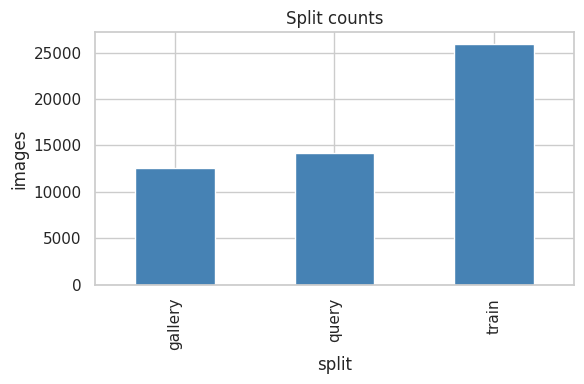

Item overlaps across splits:
  gallery vs query: 3985
  gallery vs train: 0
  query vs train: 0


In [58]:
if eval_df is not None:
    split_counts = eval_df[eval_split_col].value_counts().sort_index()
    display(split_counts)

    plt.figure(figsize=(6, 4))
    split_counts.plot(kind="bar", color="steelblue")
    plt.title("Split counts")
    plt.xlabel("split")
    plt.ylabel("images")
    plt.tight_layout()
    plt.show()

    split_items = {
        split: set(eval_df[eval_df[eval_split_col] == split][eval_item_col])
        for split in split_counts.index
    }

    overlaps = {}
    splits = list(split_items.keys())
    for i in range(len(splits)):
        for j in range(i + 1, len(splits)):
            a, b = splits[i], splits[j]
            overlaps[f"{a} vs {b}"] = len(split_items[a] & split_items[b])

    print("Item overlaps across splits:")
    for k, v in overlaps.items():
        print(f"  {k}: {v}")

## Analyze Item and Attribute Distributions

Item frequency, attribute label balance, and description statistics.

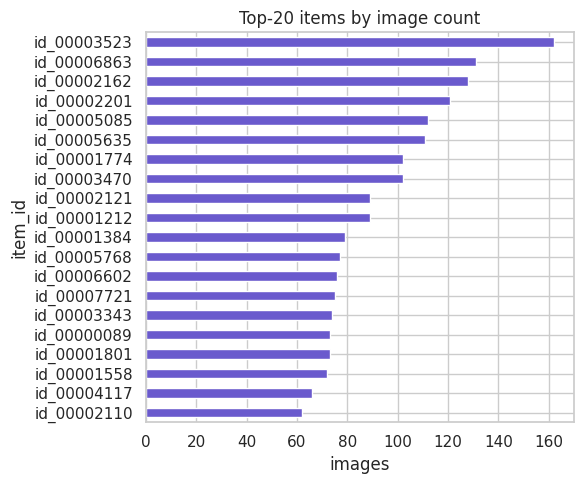

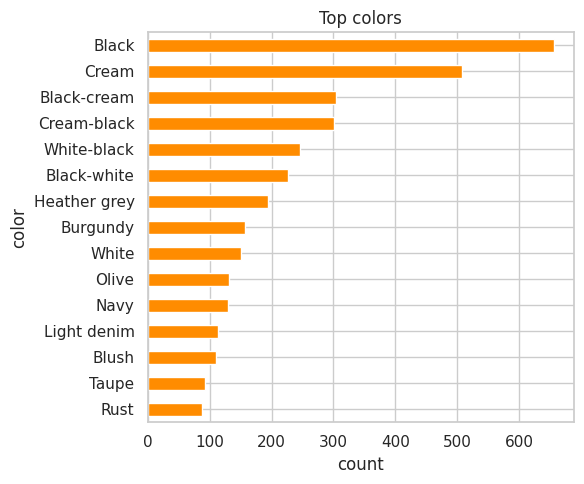

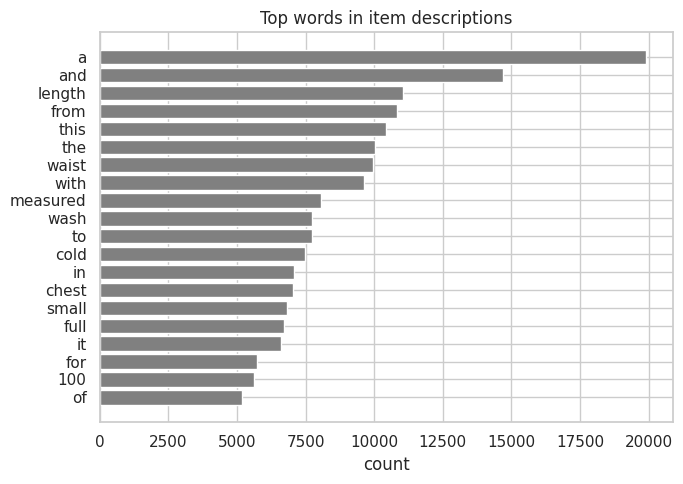

Image counts by gender


gender
MEN       7838
WOMEN    44874
Name: count, dtype: int64

Unique item counts by gender


gender
MEN       929
WOMEN    7053
Name: item_id, dtype: int64

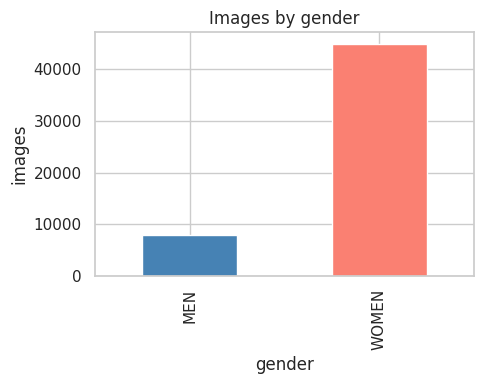

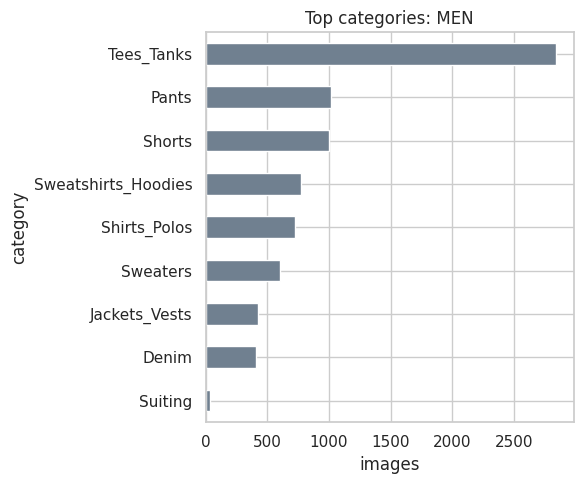

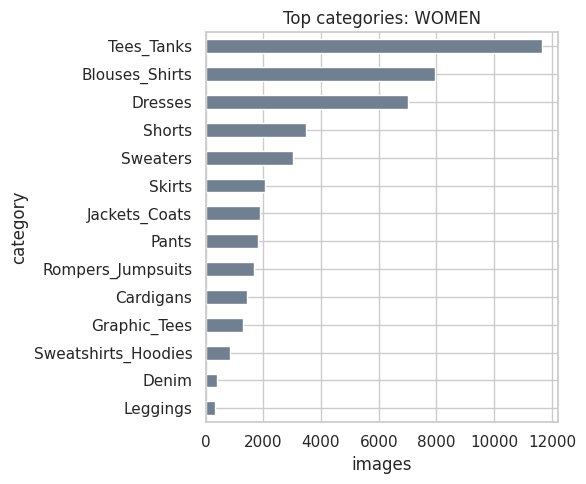

Clothes type counts by gender


clothes_type,full-body,lower-body,upper-body
gender,,,
MEN,0,2441,5397
WOMEN,8731,8053,28090


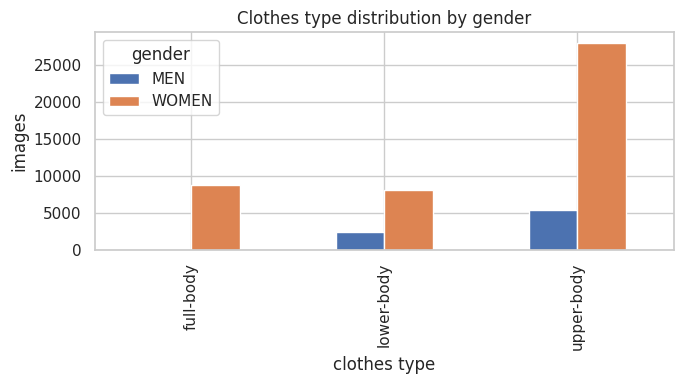

In [59]:
if eval_df is not None:
    item_counts = eval_df[eval_item_col].value_counts().head(20).sort_values()
    plt.figure(figsize=(6, 5))
    item_counts.plot(kind="barh", color="slateblue")
    plt.title("Top-20 items by image count")
    plt.xlabel("images")
    plt.ylabel("item_id")
    plt.tight_layout()
    plt.show()

if attr_items_df is not None and attr_df is not None:
    attr_names = attr_df["attribute"].tolist()
    attr_cols = [c for c in attr_items_df.columns if c != attr_items_df.columns[0]]
    if len(attr_cols) == len(attr_names):
        attr_items_df = attr_items_df.rename(columns=dict(zip(attr_cols, attr_names)))
        attr_cols = attr_names

    attr_values = attr_items_df[attr_cols].apply(pd.to_numeric, errors="coerce")
    label_counts = pd.DataFrame({
        "positive": (attr_values == 1).sum(),
        "negative": (attr_values == -1).sum(),
        "unknown": (attr_values == 0).sum(),
    })

    top_pos = (label_counts["positive"] / label_counts.sum(axis=1)).sort_values(ascending=False).head(20)
    plt.figure(figsize=(7, 6))
    top_pos.sort_values().plot(kind="barh", color="teal")
    plt.title("Top attributes by positive rate")
    plt.xlabel("positive rate")
    plt.tight_layout()
    plt.show()

if desc_df is not None:
    desc_cols = {str(c).lower(): c for c in desc_df.columns}
    color_col = desc_cols.get("color") or desc_cols.get("item_color")
    desc_col = desc_cols.get("description") or desc_cols.get("item_description")

    if color_col:
        color_counts = desc_df[color_col].value_counts().head(15).sort_values()
        plt.figure(figsize=(6, 5))
        color_counts.plot(kind="barh", color="darkorange")
        plt.title("Top colors")
        plt.xlabel("count")
        plt.tight_layout()
        plt.show()

    if desc_col:
        text = " ".join(desc_df[desc_col].dropna().astype(str))
        tokens = re.findall(r"[a-z0-9]+", text.lower())
        top_words = Counter(tokens).most_common(20)
        if top_words:
            words, counts = zip(*top_words)
            plt.figure(figsize=(7, 5))
            plt.barh(words[::-1], counts[::-1], color="gray")
            plt.title("Top words in item descriptions")
            plt.xlabel("count")
            plt.tight_layout()
            plt.show()

if eval_df is not None:
    # Gender and category breakdown from image path.
    eval_paths = eval_df[eval_img_col].astype(str)
    parts = eval_paths.str.split("/")
    gender = parts.str[1].str.upper()
    category = parts.str[2]

    gender_df = eval_df.copy()
    gender_df["gender"] = gender
    gender_df["category"] = category
    gender_df = gender_df[gender_df["gender"].isin(["MEN", "WOMEN"])].copy()

    if not gender_df.empty:
        gender_image_counts = gender_df["gender"].value_counts().sort_index()
        gender_item_counts = gender_df.groupby("gender")[eval_item_col].nunique().sort_index()
        print("Image counts by gender")
        display(gender_image_counts)
        print("Unique item counts by gender")
        display(gender_item_counts)

        plt.figure(figsize=(5, 4))
        gender_image_counts.plot(kind="bar", color=["steelblue", "salmon"])
        plt.title("Images by gender")
        plt.xlabel("gender")
        plt.ylabel("images")
        plt.tight_layout()
        plt.show()

        for g in ["MEN", "WOMEN"]:
            subset = gender_df[gender_df["gender"] == g]
            if subset.empty:
                continue
            cat_counts = subset["category"].value_counts().head(15).sort_values()
            plt.figure(figsize=(6, 5))
            cat_counts.plot(kind="barh", color="slategray")
            plt.title(f"Top categories: {g}")
            plt.xlabel("images")
            plt.ylabel("category")
            plt.tight_layout()
            plt.show()

        if bbox_df is not None and bbox_clothes_col is not None:
            merged = gender_df.merge(
                bbox_df[[bbox_img_col, bbox_clothes_col]],
                left_on=eval_img_col,
                right_on=bbox_img_col,
                how="left",
            )
            clothes_map = {1: "upper-body", 2: "lower-body", 3: "full-body"}
            merged["clothes_type"] = pd.to_numeric(merged[bbox_clothes_col], errors="coerce").map(clothes_map)
            ct_counts = (
                merged.dropna(subset=["clothes_type"])
                .groupby(["gender", "clothes_type"]).size()
                .unstack(fill_value=0)
            )
            if not ct_counts.empty:
                print("Clothes type counts by gender")
                display(ct_counts)
                ct_counts.T.plot(kind="bar", figsize=(7, 4))
                plt.title("Clothes type distribution by gender")
                plt.xlabel("clothes type")
                plt.ylabel("images")
                plt.tight_layout()
                plt.show()
    else:
        print("No gender paths found in eval_df")

## Analyze Bounding Boxes and Landmark Coverage

Spatial statistics from bbox and landmark annotations.

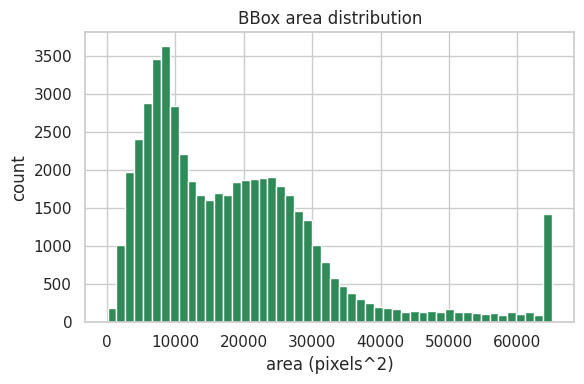

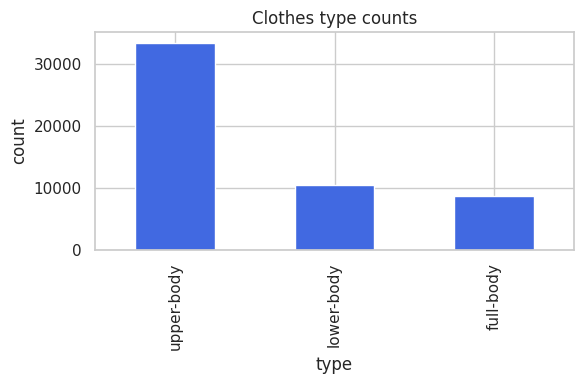

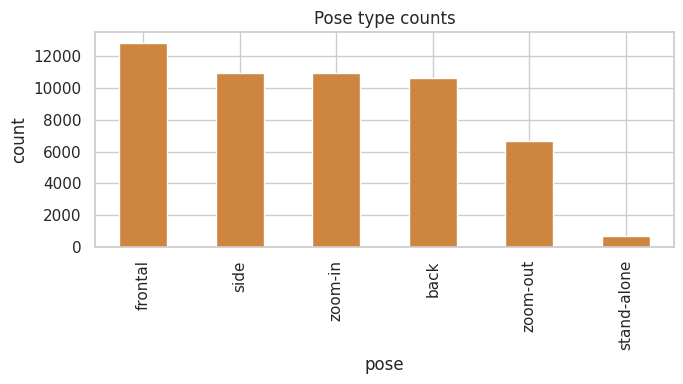

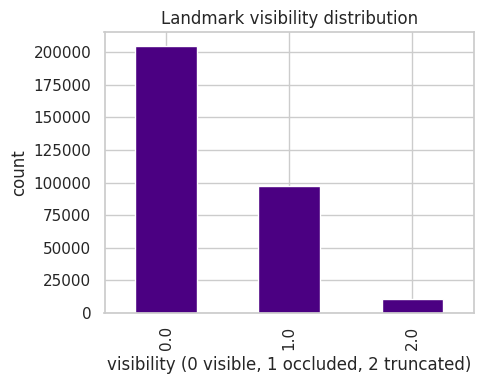

In [60]:
if bbox_df is not None:
    coord_cols = [c for c in ["x_1", "y_1", "x_2", "y_2"] if c in bbox_df.columns]
    if len(coord_cols) < 4:
        coord_cols = list(bbox_df.columns[-4:])
    x1_col, y1_col, x2_col, y2_col = coord_cols

    bbox_numeric = bbox_df[[x1_col, y1_col, x2_col, y2_col]].apply(pd.to_numeric, errors="coerce")
    width = (bbox_numeric[x2_col] - bbox_numeric[x1_col]).clip(lower=0)
    height = (bbox_numeric[y2_col] - bbox_numeric[y1_col]).clip(lower=0)
    area = width * height

    plt.figure(figsize=(6, 4))
    plt.hist(area.dropna(), bins=50, color="seagreen")
    plt.title("BBox area distribution")
    plt.xlabel("area (pixels^2)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    clothes_map = {1: "upper-body", 2: "lower-body", 3: "full-body"}
    pose_map = {1: "frontal", 2: "side", 3: "back", 4: "zoom-out", 5: "zoom-in", 6: "stand-alone"}

    ctype = pd.to_numeric(bbox_df[bbox_clothes_col], errors="coerce").map(clothes_map)
    pose = pd.to_numeric(bbox_df[bbox_pose_col], errors="coerce").map(pose_map)

    plt.figure(figsize=(6, 4))
    ctype.value_counts().plot(kind="bar", color="royalblue")
    plt.title("Clothes type counts")
    plt.xlabel("type")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    pose.value_counts().plot(kind="bar", color="peru")
    plt.title("Pose type counts")
    plt.xlabel("pose")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

if land_df is not None:
    remaining = list(land_df.columns[3:])
    visibility_cols = [c for c in remaining if "vis" in str(c).lower() or str(c).lower().startswith("v")]
    if not visibility_cols and len(remaining) >= 3:
        visibility_cols = remaining[::3]

    if visibility_cols:
        vis_values = pd.to_numeric(land_df[visibility_cols].stack(), errors="coerce").dropna()
        vis_counts = vis_values.value_counts().sort_index()
        plt.figure(figsize=(5, 4))
        vis_counts.plot(kind="bar", color="indigo")
        plt.title("Landmark visibility distribution")
        plt.xlabel("visibility (0 visible, 1 occluded, 2 truncated)")
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

## Sample Image Visualization with Annotations

Random samples with bbox and landmark overlays for sanity checks.

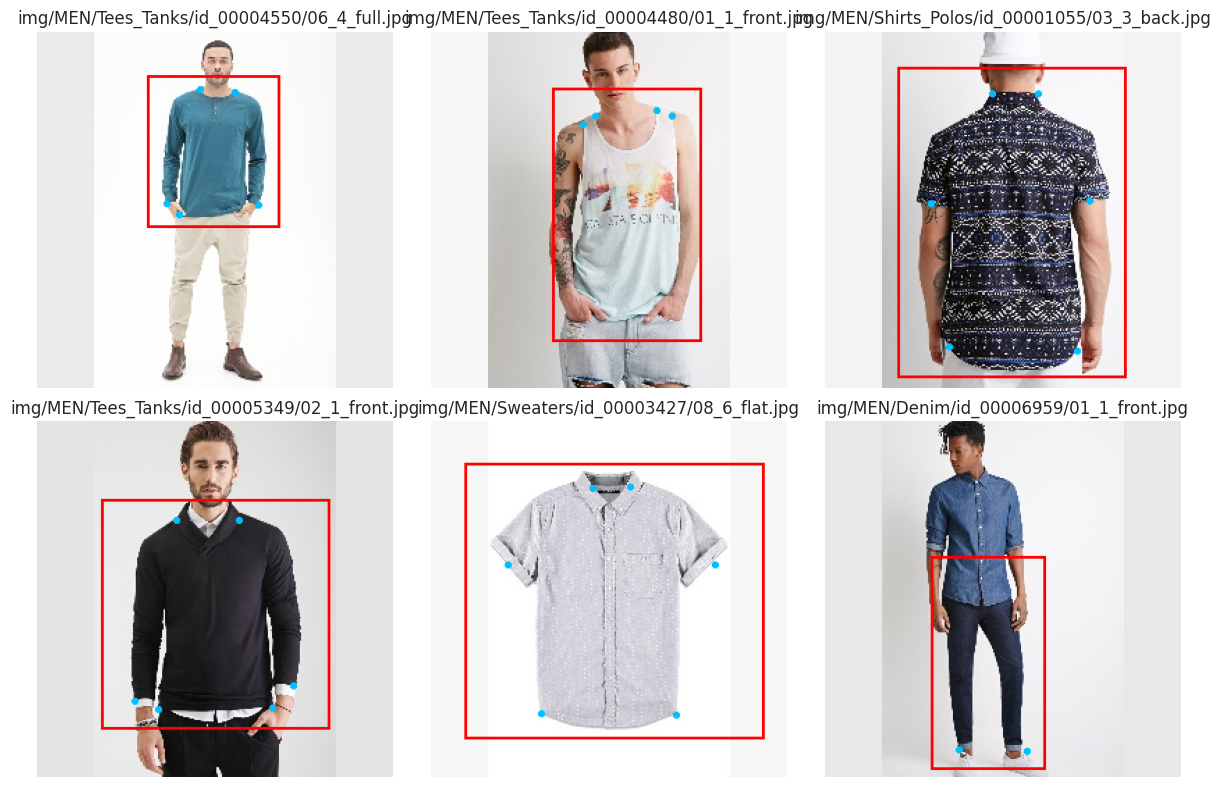

In [61]:
import math


def get_bbox_row(image_name):
    if bbox_df is None or bbox_img_col is None:
        return None
    rows = bbox_df[bbox_df[bbox_img_col] == image_name]
    if rows.empty:
        return None
    return rows.iloc[0]


def get_landmark_row(image_name):
    if land_df is None or land_img_col is None:
        return None
    rows = land_df[land_df[land_img_col] == image_name]
    if rows.empty:
        return None
    return rows.iloc[0]


def draw_annotations(image, bbox_row=None, land_row=None):
    img = image.copy()
    draw = ImageDraw.Draw(img)

    if bbox_row is not None:
        coord_cols = [c for c in ["x_1", "y_1", "x_2", "y_2"] if c in bbox_row.index]
        if len(coord_cols) < 4:
            coord_cols = list(bbox_row.index[-4:])
        x1, y1, x2, y2 = [int(float(bbox_row[c])) for c in coord_cols]
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

    if land_row is not None:
        cols = list(land_row.index)
        remaining = cols[3:]
        triplets = [tuple(remaining[i:i + 3]) for i in range(0, len(remaining) - 2, 3)]
        for v_col, x_col, y_col in triplets:
            v = land_row[v_col]
            if pd.isna(v) or int(v) != 0:
                continue
            x = int(float(land_row[x_col]))
            y = int(float(land_row[y_col]))
            r = 2
            draw.ellipse([x - r, y - r, x + r, y + r], fill="deepskyblue", outline="deepskyblue")

    return img


if eval_df is not None:
    eval_paths = eval_df[eval_img_col].astype(str)
    men_mask = eval_paths.str.lower().str.startswith("img/men/")
    sample_pool = eval_df[men_mask] if men_mask.any() else eval_df

    sample_df = sample_pool.sample(n=min(6, len(sample_pool)), random_state=RNG_SEED)
    n = len(sample_df)
    n_cols = 3
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image_name = row[eval_img_col]
        image_path = IMG_DIR / image_name
        if not image_path.exists():
            ax.axis("off")
            ax.set_title(f"Missing: {image_name}")
            continue

        img = Image.open(image_path).convert("RGB")
        bbox_row = get_bbox_row(image_name)
        land_row = get_landmark_row(image_name)
        annotated = draw_annotations(img, bbox_row=bbox_row, land_row=land_row)
        ax.imshow(annotated)
        ax.set_title(image_name)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Prepare Train/Query/Gallery Index Tables

Create clean index tables keyed by image name and item id.

In [62]:
index_tables = {}

if eval_df is not None:
    eval_clean = eval_df.copy()
    eval_clean["image_path"] = eval_clean[eval_img_col].apply(lambda p: str(IMG_DIR / p))
    splits = sorted(eval_clean[eval_split_col].unique())

    for split in splits:
        split_df = eval_clean[eval_clean[eval_split_col] == split].copy()
        if bbox_df is not None:
            split_df = split_df.merge(
                bbox_df,
                left_on=eval_img_col,
                right_on=bbox_img_col,
                how="left",
                suffixes=("", "_bbox"),
            )
        index_tables[split] = split_df
        print(f"{split}: {split_df.shape}")

    first_split = splits[0] if splits else None
    if first_split:
        display(index_tables[first_split].head())

gallery: (12612, 10)
query: (14218, 10)
train: (25882, 10)


,image_name,item_id,evaluation_status,image_path,clothes_type,pose_type,x_1,y_1,x_2,y_2
0,img/WOMEN/Blouses_Shirts/id_00000001/02_1_fron...,id_00000001,gallery,/home/saheem/Desktop/iiitb/imt2023_sem6/VR/pro...,1,1,50,49,208,235
1,img/WOMEN/Blouses_Shirts/id_00000001/02_3_back...,id_00000001,gallery,/home/saheem/Desktop/iiitb/imt2023_sem6/VR/pro...,1,3,50,42,213,240
2,img/WOMEN/Tees_Tanks/id_00000007/01_1_front.jpg,id_00000007,gallery,/home/saheem/Desktop/iiitb/imt2023_sem6/VR/pro...,1,1,66,67,205,256
3,img/WOMEN/Tees_Tanks/id_00000007/01_3_back.jpg,id_00000007,gallery,/home/saheem/Desktop/iiitb/imt2023_sem6/VR/pro...,1,3,72,40,168,220
4,img/WOMEN/Dresses/id_00000008/02_3_back.jpg,id_00000008,gallery,/home/saheem/Desktop/iiitb/imt2023_sem6/VR/pro...,3,3,73,42,186,243


## Export Cleaned Metadata for Training

Save processed tables and summary stats for downstream scripts.

In [63]:
OUTPUT_DIR = DATA_ROOT / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if index_tables:
    for split, df in index_tables.items():
        out_csv = OUTPUT_DIR / f"{split}_index.csv"
        df.to_csv(out_csv, index=False)

        out_parquet = OUTPUT_DIR / f"{split}_index.parquet"
        try:
            df.to_parquet(out_parquet, index=False)
        except Exception as exc:
            print(f"Parquet save failed for {split}: {exc}")

summary = {}
if eval_df is not None:
    summary["split_counts"] = eval_df[eval_split_col].value_counts().to_dict()
if bbox_df is not None:
    summary["bbox_rows"] = len(bbox_df)
if land_df is not None:
    summary["landmark_rows"] = len(land_df)

with (OUTPUT_DIR / "summary_stats.json").open("w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved outputs under: {OUTPUT_DIR}")

Saved outputs under: /home/saheem/Desktop/iiitb/imt2023_sem6/VR/project2/github_repo/DeepFashion-In-shop-Clothes-Retrieval_/data/processed
